In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as mticker
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import json
import os
from utils import OUT_PATH, FREQ_BAND, ExcludSubj, cleandfdecodingTS, EVENT_ID, DataTransformationM1, gaussian_filter1d

from scipy.stats import spearmanr

tfr_path = OUT_PATH + '/Data_longWOBS'
event= list(EVENT_ID.keys())[:2]
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('_TFRtrials.p'):] == '_TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_epoch = d['time_epoch']
    time_tfr=d['time_tfr']



col_pc = {0:"#0072B2", 1:"#D55E00", 2:"#009E73", 4:"#009E73"}
colors = plt.get_cmap('tab10')

element_colors = {elem: colors(i % 10) for i, elem in enumerate(FREQ_BAND)}

event_idx = {0: 'Old', 1:'New'}
color_event = {0: 'b', 1:'r'}

In [3]:
models = {
    'broadband0': ('duplicat', 'SVC_linear'), 'broadband1': ('mean', 'RandomForest'), "broadband2": ('duplicat', 'RandomForest'),
    'theta0': ('duplicat', 'RandomForest'), 'theta1':( 'mean', 'SVC_linear'), "theta2" : ('mean', 'RandomForest'),
    'alpha0': ('mean', 'LR'), 'alpha1':( 'mean', 'LR'), "alpha2" : ( 'mean', 'RandomForest'),
    'low_beta0': ('mean', 'LR'), 'low_beta1':( 'mean', 'LR'), "low_beta2" : ( 'mean', 'RandomForest'),
    'high_beta0': ('mean', 'LR'), 'high_beta1':( 'duplicat', 'LR'), "high_beta2" : ( 'mean', 'RandomForest'),
    'high_gamma0': ('duplicat', 'RandomForest'), 'high_gamma1':('duplicat', 'RandomForest'), "high_gamma2" : ( 'mean', 'RandomForest') }

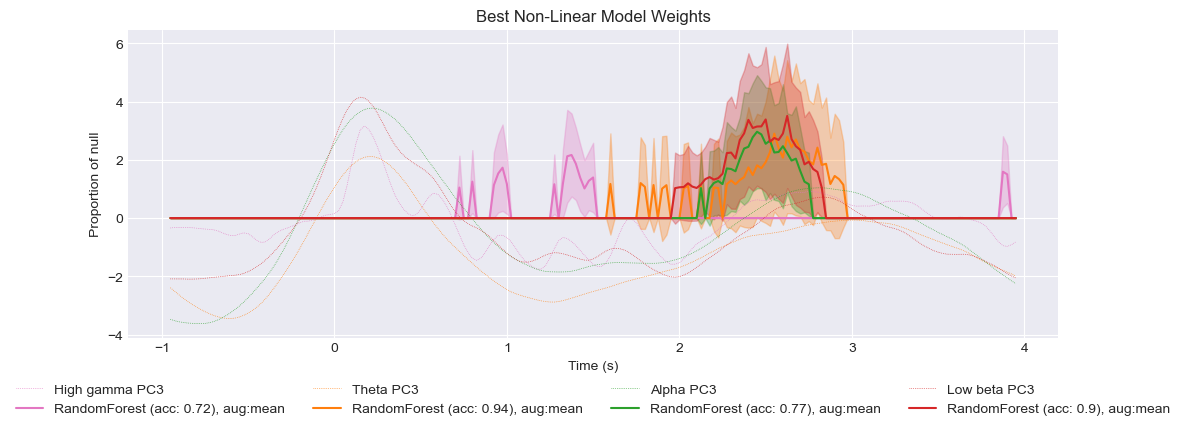

In [3]:

signals = [('high_gamma', 'concat', 2), ('theta', 'concat',2), ('alpha', 'concat',2), ('low_beta', 'concat',2)]
time = time_tfr
time_lenght = len(time)
fig, ax = plt.subplots(figsize = (12, 4))
for band, method_pca, pc_use in signals :
    ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')

    for col in ['expl_var', 'compo', 'freq', 'subj'] : 
        if col in ts.columns : 
            ts = ts.drop(columns = col)

    ts = ts.to_numpy()
    ts_pc=np.concat([ts[None, pc_use, :int(ts.shape[1]/2)], ts[None, pc_use, int(ts.shape[1]/2):]], axis = 0)
    
    data_aug_method = models[band + str(pc_use)][0]
    model = models[band + str(pc_use)][1]
    df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{pc_use}_{model}full.csv')
    result = cleandfdecodingTS(df_final, time_lenght)
    
    if result['acc'] < 0.6 :
        continue

    label_plot = f'{model.replace("_", " ")} (acc: {np.round(result["acc"], 2)}), aug:{data_aug_method}'
    weight= abs(result['weight'])
    weight_mean_std = abs(result['weight_std'])
    weight_sh_mean= abs(result['weight_sh_mean'])
    weight_sh_std= abs(result['weight_sh_std'])
    weight_prop =  weight/(weight_sh_mean+ weight_sh_std)
    #weight_prop = np.where(weight <  weight_sh_mean + weight_sh_std, 0, weight)[0]
    weight_prop_mean= np.mean(weight_prop, axis=0) 
    weight_prop_mean = np.where(weight_prop_mean > 1, weight_prop_mean, 0)
    weight_prop_std = np.where(weight_prop_mean >1, np.std(weight_prop, axis=0), 0)

    ax.plot(time, ts_pc[0, :], ls = ':', linewidth = 0.5, label = band.capitalize().replace('_', ' ') + ' PC' + str(pc_use+1), c= element_colors[band] ) #c=col_pc[pc_use])
    ax.plot(time, weight_prop_mean, label = label_plot, c=element_colors[band]) #c=col_pc[pc_use])
    ax.fill_between(time, weight_prop_mean - weight_prop_std, weight_prop_mean + weight_prop_std , alpha = 0.3,   color=element_colors[band]) #color=col_pc[pc_use])

ax.grid()
ax.set_xlabel('Time (s)')
ax.set_title('Best Non-Linear Model Weights')
ax.set_ylabel('Proportion of null')
ax.legend(bbox_to_anchor=(0.5, -0.2), ncol = 4, loc='center')


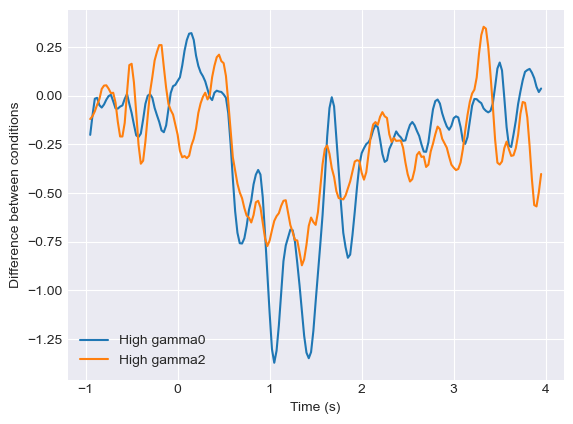

In [4]:
signals = [('high_gamma', 'concat', 0), ('high_gamma', 'concat', 2)]

label_plt = ''

for band, method_pca, pc in signals :
    # Get data
    ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')
    for col in ['expl_var', 'compo', 'freq', 'subj'] : 
        if col in ts.columns : 
            ts = ts.drop(columns = col)
 
    ts = ts.values
    ts_pc=np.concat([ts[None, :, :int(ts.shape[1]/2)], ts[None, :, int(ts.shape[1]/2):]], axis = 0)

    if band == 'alpha' :  # flip alpha
        ts_pc[:, 1, :] = - ts_pc[:, 1,:]


    # PLOT TS
    plt.plot(time_tfr, ts_pc[0, pc, :].T - ts_pc[1, pc, :].T, label = band.capitalize().replace('_', ' ') + str(pc))
plt.xlabel('Time (s)')
plt.ylabel('Difference between conditions')
plt.legend()
plt.grid()


## PEAKS

In [31]:
from scipy.signal import find_peaks

def computeLagPeak(data_condi, time, win_high, method_pca, pc1=0, pc2=1, show=True, save=False, out_path =OUT_PATH, dis=60, diff=True) : 
    peaks_coni1 = {c:[] for c in [pc1, pc2]}
    if diff: 
        fig, ax = plt.subplots(3, 1, figsize=(12, 9))
        fig.suptitle(f'Peaks detection on PC1 and 2 time series -- {method_pca} PCA')
    lag_peak_time = []
    c=["#0072B2", "#D55E00", "#009E73"]

    for ie, i in enumerate([pc1, pc2]) : 
        for win, high in win_high[i]:
            coni = data_condi[i]
            peaks, _ = find_peaks(coni[win[0]:win[1]], height=high, distance=dis)
            peaks_coni1[i].extend([p + win[0] for p in peaks])

        if diff:
            if i == pc2 : 
                mul = -1
            else : 
                mul = 1
            ax[ie].plot(mul*coni, c=c[i], label=f'PC {i+1} Time series')
            for p in peaks_coni1[i] :
                ax[ie].scatter(p, mul*coni[p], color='red', label='Detected Peaks')
            ax[ie].set_title(f'PC {i+1}')
            ax[ie].grid()

    for j in range(len(peaks_coni1[0])) :
        if diff == True : 
            lag_peak_time.append(time[np.array(peaks_coni1[pc1][j])]- time[np.array(peaks_coni1[pc2][j])])
        if diff == False : 
            lag_peak_time.append((time[np.array(peaks_coni1[pc1][j])], time[np.array(peaks_coni1[pc2][j])]))
    
    mean_lag = np.mean(lag_peak_time)
    std_lag = np.std(lag_peak_time)

    if diff :
        ax[2].plot(time, data_condi[pc1], label='PC'+str(pc1+1), c=c[pc1])
        ax[2].plot(time + mean_lag, - data_condi[pc2], label='PC' +str(pc2+1), c=c[pc2])
        ax[2].set_title('PC2 shifted by mean lag')
        ax[2].set_xlabel('Time (s)')
        ax[2].legend()
        ax[2].grid()
        #ax[2].text(s=f'Mean lag : {np.round(mean_lag, 3)}s ± {np.round(std_lag, 3)}s', x=-0.5, y=-4)
        if show :
            plt.show()
        if save :
            fig.savefig(out_path + f'/lagPeak_{method_pca}.png')

    return lag_peak_time

In [171]:
data.shape

(5, 395)

In [192]:
lag_dict={'mean_old':[], 'mean_new':[], 'concat_old':[], 'concat_new':[]}
pca_method = 'concat'
band = 'high_gamma'
data= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{pca_method}/grp_{method_pca}_Xtrans_PCA5.csv').query('freq == @band').drop(columns = ['Unnamed: 0', 'freq', 'compo', 'subj', 'expl_var']).values #, 'expl_var']).values
data = np.concat([[data[:, :int(data.shape[1]/2)]], [data[:, int(data.shape[1]/2):]]], axis=0)

data[:, 2, :] = -data[:, 2, :]
#data[:, 0, :] = -data[:,0, :]
data[:, 1, :] = -data[:,1, :]

for i_condi, condi in enumerate(['old', 'new']) : 
    coni = pd.DataFrame(data[i_condi, :,:].T).T

    if band == 'high_gamma' : 
        dist = 10
        time=time_tfr
        if condi == 'new' :
            win_high = {0 : [([25, 125], 3)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2 : [([40, 125], -1)]}
        elif condi == 'old' :
            win_high = {0 :  [([25, 125], 3)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([25, 125], -1)]}
    if band == 'broadband' :
        dist = 60
        time=time_epoch
        if condi == 'new' :
            win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([250, 310], -0.005), ([350, 630], 0.00)]}
        elif condi == 'old' :
            win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([250, 310], -0.005), ([350, 400], 0.0025), ([400, 620], -0.0025)]}


    lag = computeLagPeak(coni.values, time, win_high, method_pca=pca_method, show=True, dis=dist, pc1=0, pc2=0, diff=False)
    lag_dict[f'{pca_method}_{condi}'].extend(lag)


In [193]:
np.mean(lag_dict['mean_new'] + lag_dict['mean_old'] )
np.std(lag_dict['mean_new'] + lag_dict['mean_old'] )


/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

In [194]:
np.mean(lag_dict['concat_old'])


np.float64(0.9550000000000018)

In [196]:
[np.round(l[0], 2) for l in lag_dict['concat_old']]

[np.float64(0.18),
 np.float64(0.6),
 np.float64(0.98),
 np.float64(1.33),
 np.float64(1.7),
 np.float64(0.18),
 np.float64(0.6),
 np.float64(0.98),
 np.float64(1.33),
 np.float64(1.7)]

In [182]:
lag_dict[('concat_old')]

[]

In [174]:
lag_dict={'mean_old': [], 'mean_new': [], 'concat_old':[], 'concat_new':[]}

for pca_method in ['mean'] : #, 'concat'] :
    data= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{pca_method}/grp_Xtrans_PCA5.csv').query('freq == "broadband"').drop(columns = ['Unnamed: 0', 'freq', 'compo', 'subj']).values #, 'expl_var']).values
    data = np.concat([[data[:, :int(data.shape[1]/2)]], [data[:, int(data.shape[1]/2):]]], axis=0)
    data[:, 1, :] = -data[:, 1, :]
    data[:, 0, :] = -data[:,0, :]

    for i_condi, condi in enumerate(['old', 'new']) : 
        coni = pd.DataFrame(data[i_condi, :,:].T).T

        if condi == 'new' :
            win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([200, 280], 0.005), ([300, 400], 0.0025), ([400, 600], -0.0025)]}
        elif condi == 'old' :
            win_high = {0 : [([200, 280], 0.005), ([300, 500], 0.006), ([500, 700], 0.005)], 
            1: [([200, 230], 0), ([300, 550], -0.005)], 2: [([200, 280], 0.005), ([300, 400], 0.0025), ([400, 600], -0.0025)]}

        lag = computeLagPeak(coni.values, time_epoch, win_high, method_pca=pca_method, show=True,diff=False,  dis=60, pc1=0, pc2=1)
        lag_dict[f'{pca_method}_{condi}'].extend(lag)

## SLOPS

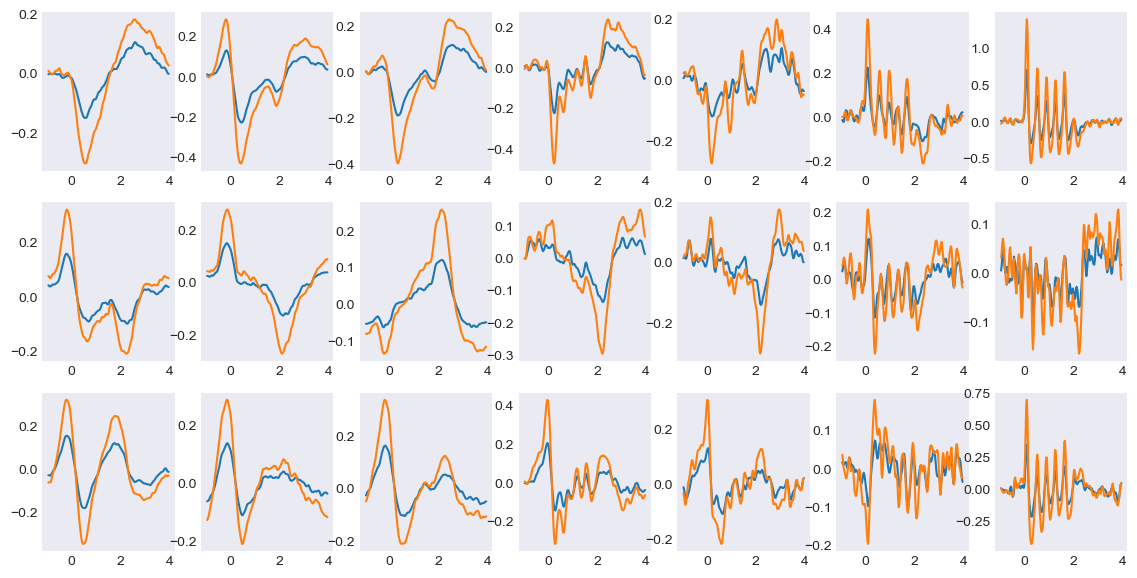

In [ ]:
# on ts
method_pca = 'concat'
ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0'])

for col in ['expl_var', 'compo', 'freq', 'subj'] : 
    if col in ts.columns : 
        ts = ts.drop(columns = col)

ts = ts.values.reshape([7, 5, -1])
ts=np.concat([ts[None, :,  :, :int(ts.shape[2]/2)], ts[None, :, :,  int(ts.shape[2]/2):]], axis = 0)
fig, ax = plt.subplots(3, 7, figsize = (14, 7))

grad = np.zeros_like(ts) 
for pc in range(3) :
    for condi in range(ts.shape[0]):
        for freq in range(ts.shape[1]) : 
            grad[condi, freq, pc, :] = np.gradient(ts[condi, freq, pc, :])
            ax[pc][freq].plot(time_tfr, grad[:, freq, pc, :].mean(0), ls = '-')

In [ ]:
# on weights of clf
band = 'high_gamma'
method_pca = 'concat'
data_aug_method = 'mean'
model_name = 'RandomForest'
time = time_tfr
from utils import cleandfdecodingTS

grad_list = []
for PC_use in [0, 2] : 

    df_final = pd.read_csv(OUT_PATH + f'/Decoding/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full.csv') #_crp18_197_

    result = cleandfdecodingTS(df_final, len(time))
    w =result['weight']
    w_sh = result['weight_sh_mean']
    w_std = result['weight_sh_std']
    w = np.where(w > w_sh + 2*w_std, w, 0)

    grad = np.zeros_like(w) 
    for r in range(100) :
        grad[r,  :] = np.gradient(w[r, :])
    grad_list.append(grad)

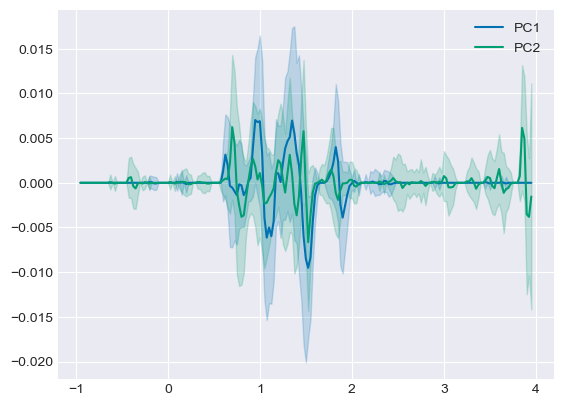

In [ ]:
plt.plot(time_tfr, grad_list[0].mean(0), label = 'PC1', c=col_pc[0])
plt.fill_between(time_tfr, grad_list[0].mean(0) - grad_list[0].std(0), grad_list[0].mean(0) + grad_list[0].std(0), color=col_pc[0], alpha = 0.2)
plt.plot(time_tfr, grad_list[1].mean(0), label = 'PC2', c=col_pc[2])
plt.fill_between(time_tfr, grad_list[1].mean(0) - grad_list[1].std(0), grad_list[1].mean(0) + grad_list[1].std(0), color=col_pc[2], alpha = 0.2)
plt.grid()

#plt.plot(time_tfr, w.mean(0), ls=':')
plt.legend()

## specific time point

In [112]:
method_pca = 'mean'
band = 'broadband'
data_aug_method = 'duplicat'
PC_use = 2
nb_compo =PC_use+1

ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{method_pca}/grp_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band').drop(columns = ['subj', 'compo', 'freq']).values #'expl_var'
ts = np.concat([ts[None, :, :int(ts.shape[1]/2)], ts[None, :, int(ts.shape[1]/2):]], axis=0)

In [113]:
from utils import DataTransformationM1

X_train, y_train, X_test, y_test, _, _ = DataTransformationM1(freq= band, method_pca=method_pca, nb_compo=nb_compo, data_aug_method=data_aug_method, subj_included=subj_included, PC_use=PC_use, data_path=tfr_path)           
X = np.concat([X_train, X_test])
y = np.concat([y_train, y_test])
id_old = np.where(y ==1)[0]
id_new = np.where(y ==2)[0]
X = np.concat([X[None, id_old, :], X[None, id_new, :]], axis=0)

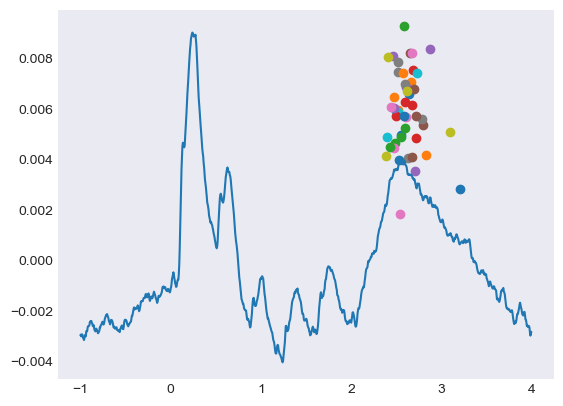

In [126]:
old = []
new=[]
for im in range(X.shape[1]) : 
    old_id = list(X[0, im, 600:]).index(np.max(X[0, im, 600:]))
    new_id = list(X[1, im, 600:]).index(np.max(X[1, im, 600:]))

    plt.scatter(time_epoch[600 + old_id], X[0, im,600 + old_id])

    plt.scatter(time_epoch[600 + new_id], X[1, im,600 + new_id])

    old.append(time_epoch[600 + old_id])
    new.append(time_epoch[600 + new_id])
plt.plot(time_epoch, X[0, :, :].mean(0))
plt.show()

In [127]:
np.mean(old)

np.float64(2.6058333333333334)

In [130]:
np.std(new)

np.float64(0.11212901795104897)

In [128]:
np.mean(new)

np.float64(2.6225)

In [132]:
def robust_pos_to_neg_crossings(x):
        theta = 0
        min_samples=4
        crossings = []
        n = len(x)

        for i in range(n - min_samples - 1):
            
            # Step A — candidate sign flip
            if x[i] > theta and x[i+1] < -theta:
                
                # Step B — verify sustained positivity BEFORE
                if not np.all(x[max(0, i-min_samples):i] > theta):
                    continue

                # Step C — verify sustained negativity AFTER
                if not np.all(x[i+1:i+1+min_samples] < -theta):
                    continue

                crossings.append(i)

        return np.array(crossings)

    

IndexError: index 134 is out of bounds for axis 0 with size 120

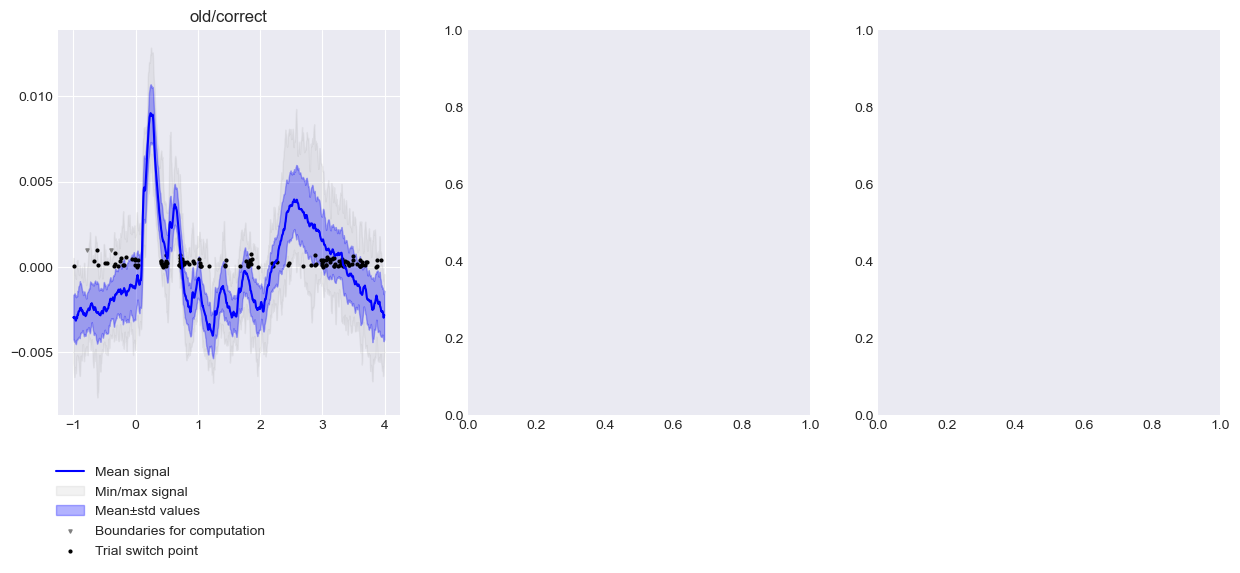

In [136]:
time = time_epoch

fig, axs = plt.subplots(1, 3, figsize = (15, 5))
for condi, ax in enumerate(axs[:2]) :
    ax.plot(time, X[condi, :, :].mean(0), c=color_event[condi], label = 'Mean signal')
    ax.fill_between(time, X[condi, :, :].min(0) ,X[condi, :, :].max(0), alpha= 0.1, color = 'grey', label = 'Min/max signal')
    ax.fill_between(time, X[condi, :, :].mean(0) - X[condi, :, :].std(0) ,X[condi, :, :].mean(0) + X[condi, :, :].std(0), alpha= 0.3,color = color_event[condi], label = 'Mean±std values')
    ax.scatter([time[45], time[120]], [0.001, 0.001], marker='v', c='grey', s=5, label='Boundaries for computation')
    #X_crp = X[:, :, 45:120] # high gamma switch 
    X_crp = X
    #delay = 45
    delay = 0

    all_cro =[]

    for im in range(X.shape[1]) :
        crossings = robust_pos_to_neg_crossings(X_crp[condi, im, :])
        all_cro.extend(crossings)
        for c, cro in enumerate(crossings) : 
            if im == 0 and c ==0:
                ax.scatter(time[delay+cro], X[condi, im, delay+cro], s = 4, c='k', label = 'Trial switch point')

            else :
                ax.scatter(time[delay+cro], X[condi, im, delay+cro], s = 4, c='k')


    ax.grid()
    ax.set_title(event[condi])
    ax.legend(bbox_to_anchor = (0.3, -0.1), loc='upper center' )
    axs[2].hist(np.array(time[delay:120])[all_cro], color=color_event[condi], alpha = 0.3, label = event[condi])

    time_cross = np.array(time[delay:120])[all_cro]

    mean_tp = np.mean(time_cross[np.where((time_cross > 0.45) & (time_cross < 1))[0]])
    std_tp = np.std(time_cross[np.where((time_cross > 0.45) & (time_cross < 1))[0]])
    print(event[condi], np.round(mean_tp, 2), np.round(std_tp, 2))
    #p_int = np.where((time_cross > 0.45) & (time_cross < 1))[0]
    #for c, cro in enumerate(p_int) : 
    #    ax.scatter(time_cross[cro], 0, s = 4, c='g')

    
    ax.set_xlabel('Time (s)')
axs[2].grid()
axs[2].legend()
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Count of switch points')
axs[2].set_title('Switching polarity point accross trials')

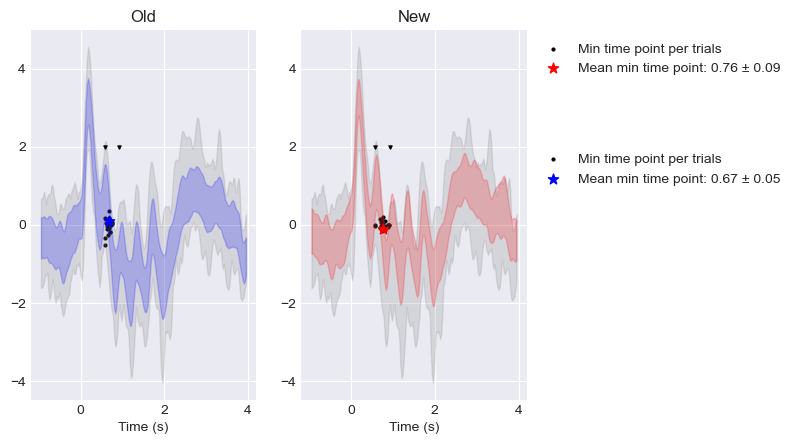

In [50]:
fig, ax= plt.subplots(1, 2)
for condi in [0, 1]:
    id_min = []
    for im, m in enumerate(np.min(np.abs(X[condi, :, 61:75]), axis = 1)) : 
        try : 
            the_min = list(X[condi, im, :]).index(m)
        except :
            the_min = list(X[condi, im, :]).index(-m)

        id_min.append(the_min)

    for i, t in enumerate(id_min) :
        if i==0:
            ax[condi].scatter(time_tfr[t], X[condi, i, t], label = 'Min time point per trials', c='k', s=4)
        else : 
            ax[condi].scatter(time_tfr[t], X[condi, i, t], c='k', s=4)

    ax[condi].fill_between(time_tfr, X[0, :, :].min(0) ,X[0, :, :].max(0), alpha= 0.2, color='grey')
    ax[condi].fill_between(time_tfr, X[condi, :, :].mean(0)-X[0, :, :].std(0), X[condi, :, :].mean(0) + X[condi, :, :].std(0), alpha = 0.2, color=color_event[condi])

    #ax[condi].scatter(time_tfr[list(X[0, :, :].std(0)).index(min(X[0, :, :].std(0)))], X[condi, :, list(X[0, :, :].std(0)).index(min(X[0, :, :].std(0)))].mean(0), label = 'Minimal variance across trials', marker= '^')
    ax[condi].grid()
    ax[condi].set_title(event_idx[condi])
    ax[condi].scatter([time_tfr[61], time_tfr[75]], [2, 2], marker='v',color='k', s=5)
    mean_time = np.mean([time_tfr[i] for i in id_min])
    std_time = np.std([time_tfr[i] for i in id_min])
    ax[condi].scatter(mean_time, X[condi, :, id_min].mean(), marker ='*',s =60,  label = f'Mean min time point: {np.round(mean_time, 2)} ± {np.round(std_time, 2)}', c=color_event[condi])
    ax[condi].set_xlabel('Time (s)')

    ax[condi].legend(bbox_to_anchor=(1 + (condi-1)*(-2.38), 1 +(condi-1)*(0.3)))



## PC3 char

In [7]:
import numpy as np

results = {} 

method_pca = 'concat'
data_aug_method = 'mean'
PC_use = 2
nb_compo = PC_use + 1

for band in FREQ_BAND:
    results[band] = {
        "first_peak_time": {},
        "first_peak_amp": {},
        "switch_time": {},
        "last_peak_time": {},
        "last_peak_amp": {},
        "switch_amp":{}
    }

    X_train, y_train, X_test, y_test, _, _ = DataTransformationM1(
        freq=band, method_pca=method_pca, nb_compo=nb_compo,
        data_aug_method=data_aug_method, subj_included=subj_included,
        PC_use=PC_use, data_path=tfr_path
    )

    X = np.concatenate([X_train, X_test])
    y = np.concatenate([y_train, y_test])

    id_old = np.where(y == 1)[0]
    id_new = np.where(y == 2)[0]
    X = np.concatenate([X[None, id_old, :], X[None, id_new, :]], axis=0)
    #X = gaussian_filter1d(X, sigma = 5)
    for condi in [0, 1]:

        # ---------- FIRST PEAK ----------
        id_peak = []
        for im, m in enumerate(np.max(X[condi, :, :70], axis=1)):
            try:
                idx = list(X[condi, im, :]).index(m)
            except:
                idx = list(X[condi, im, :]).index(-m)
            id_peak.append(idx)

        times = np.array([time_tfr[i] for i in id_peak])
        amps = X[condi, np.arange(len(id_peak)), id_peak]

        results[band]["first_peak_time"][condi] = (times.mean(), times.std())
        results[band]["first_peak_amp"][condi] = (amps.mean(), amps.std())

        # ---------- LAST PEAK ----------
        id_peak = []
        for im, m in enumerate(np.max(X[condi, :, 70:], axis=1)):
            try:
                idx = list(X[condi, im, :]).index(m)
            except:
                idx = list(X[condi, im, :]).index(-m)
            id_peak.append(idx)

        times = np.array([time_tfr[i] for i in id_peak])
        amps = X[condi, np.arange(len(id_peak)), id_peak]

        results[band]["last_peak_time"][condi] = (times.mean(), times.std())
        results[band]["last_peak_amp"][condi] = (amps.mean(), amps.std())

        # ---------- SWITCH (timing only) ----------
        id_switch = []
        for im, m in enumerate(np.min(np.abs(X[condi, :, 40:90]), axis=1)):
            try:
                idx = list(X[condi, im, :]).index(m)
            except:
                idx = list(X[condi, im, :]).index(-m)
            id_switch.append(idx)

        times = np.array([time_tfr[i] for i in id_switch])
        amps = X[condi, np.arange(len(id_switch)), id_switch]
        results[band]["switch_time"][condi] = (times.mean(), times.std())
        results[band]["switch_amp"][condi] = (amps.mean(), amps.std())


In [ ]:
method_pca = 'concat'
data_aug_method = 'mean'
PC_use = 2
model_name = 'LR'

deco_acc = {'All':[], 'Baseline':[], 'W/O Baseline':[]}

for band in FREQ_BAND : 
    if band == 'low_gamma' or 'high_beta': continue
    df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full.csv') #_crp18_197_
    result = cleandfdecodingTS(df_final, len(time_tfr))
    deco_acc['All'].append(result['acc'])

    df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full_crp0_18_.csv') #_crp18_197_
    result = cleandfdecodingTS(df_final, len(time_tfr[0:18]))
    deco_acc['Baseline'].append(result['acc'])

    df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full_crp18_197_.csv') #_crp18_197_
    result = cleandfdecodingTS(df_final, len(time_tfr[18:197]))
    deco_acc['W/O Baseline'].append(result['acc'])



FileNotFoundError: [Errno 2] No such file or directory: 'outs/Decoding_shuffled_trials/high_beta/fullmodel/concat_mean_2_LRfull.csv'

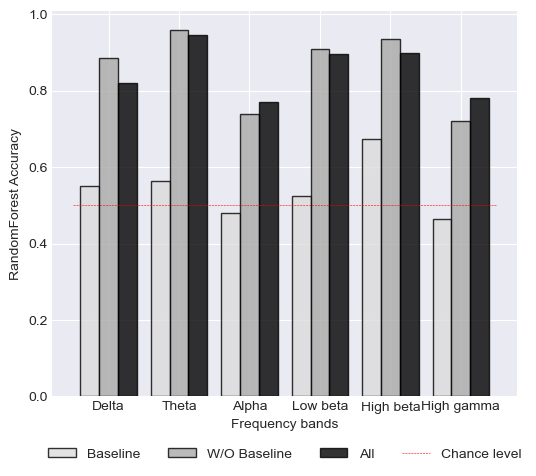

In [ ]:
acc = pd.DataFrame(deco_acc)
band = FREQ_BAND.copy()
band.remove('low_gamma')
acc['band']= [b.replace('_', ' ').capitalize() for b in band]

acc_long = acc.melt(id_vars='band', value_vars=['Baseline', 'W/O Baseline', 'All'],
                    var_name='Time Sequence', value_name='accuracy')

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=acc_long,
    x='band',
    y='accuracy',
    hue='Time Sequence',
    palette={'All': 'black', 'Baseline': 'gainsboro', 'W/O Baseline' : 'darkgrey'},  
    edgecolor='black',
    alpha = 0.8
)
ax.plot(np.arange(len(FREQ_BAND)) -0.5, [0.5]*(len(FREQ_BAND)), label ='Chance level', c='r', ls='--', linewidth = 0.4)

ax.set_ylabel("RandomForest Accuracy")
ax.set_xlabel("Frequency bands")
ax.grid()

ax.legend(bbox_to_anchor = (0.5,-0.15), ncol=4, loc='center')

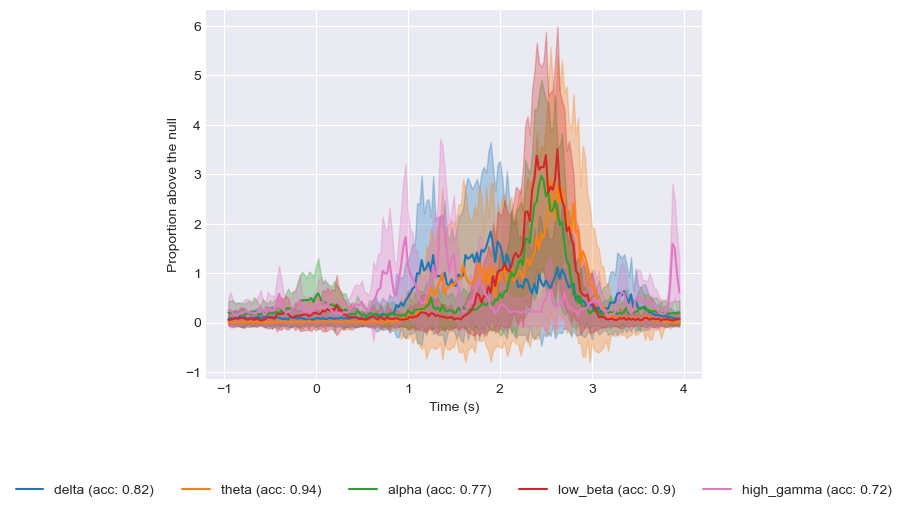

In [9]:
method_pca = 'concat'
data_aug_method = 'mean'
PC_use = 2
model_name = 'RandomForest'
time = time_tfr

deco_dict = {}

for band in FREQ_BAND : 
    if band in ['low_gamma', 'high_beta']: continue
    df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full.csv') #_crp18_197_
    result = cleandfdecodingTS(df_final, len(time))
    weight= abs(result['weight'])
    weight_mean_std = abs(result['weight_std'])
    weight_sh_mean= abs(result['weight_sh_mean'])
    weight_sh_std= abs(result['weight_sh_std'])
    weight_prop = weight/(weight_sh_mean+weight_sh_std)

    weight_prop_std = np.std(weight_prop, axis=0)
    weight_prop_mean= np.mean(weight_prop, axis=0)
    
    plt.fill_between(time, weight_prop_mean - weight_prop_std, weight_prop_mean + weight_prop_std, alpha=0.3, color =element_colors[band])
    plt.plot(time, weight_prop_mean, c=element_colors[band], label = band +  f' (acc: {np.round(result["acc"], 2)})')

    w = np.where(weight > weight_sh_mean + 2*weight_sh_std, weight, 0)

    deco_dict[band] = weight_prop

plt.legend(bbox_to_anchor = (0.5, -0.3), ncol=5, loc='center')
plt.xlabel('Time (s)')
plt.ylabel('Proportion above the null')
plt.grid()


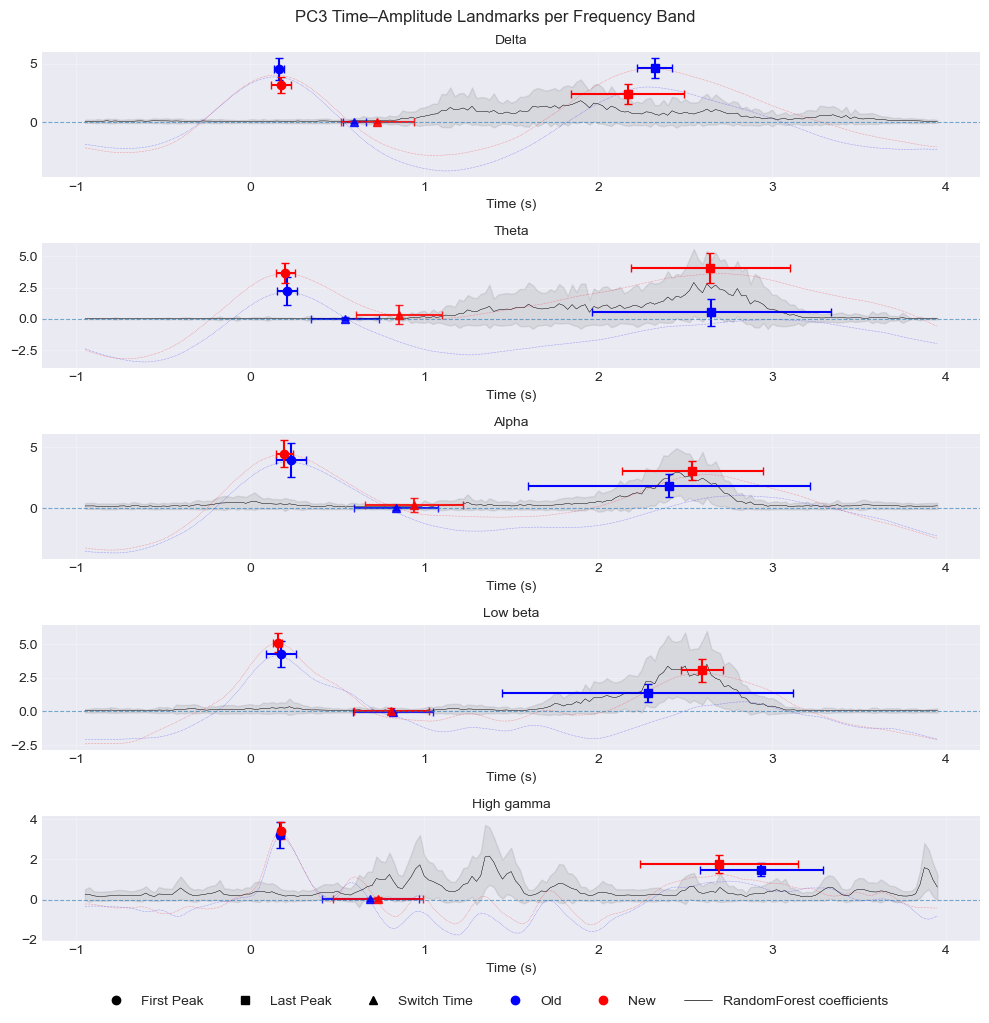

In [10]:
import numpy as np
import matplotlib.pyplot as plt

bands = list(results.keys())
bands.remove('low_gamma')
bands.remove('high_beta')
cond_labels = ["Old", "New"]

fig, axes = plt.subplots(
    len(bands),1,
    figsize=(10, 2*len(bands)))

if len(bands) == 1:
    axes = [axes]

for ax, band in zip(axes, bands):
    ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band').drop(columns = ['subj', 'expl_var', 'compo', 'freq']).values
    ts = np.concat([ts[None, :, :int(ts.shape[1]/2)], ts[None, :, int(ts.shape[1]/2):]], axis=0)

    for condi in [0, 1]:
        # ----- coef of CLF -----
        ax.fill_between(time_tfr, deco_dict[band].mean(axis=0) - deco_dict[band].std(axis=0), deco_dict[band].mean(axis=0) + deco_dict[band].std(axis=0), alpha=0.04, color ='k')
        ax.plot(time_tfr, deco_dict[band].mean(axis=0), c='k', label = band, linewidth=0.2)

        # ----- Undelying ts -----
        ax.plot(time_tfr, ts[condi, 2, :], c=color_event[condi], ls=':', linewidth=0.4, alpha = 0.6)

        # ----- FIRST PEAK -----
        t_mean, t_std = results[band]["first_peak_time"][condi]
        a_mean, a_std = results[band]["first_peak_amp"][condi]
        ax.errorbar(t_mean, a_mean, xerr=t_std, yerr=a_std,
                    fmt='o', color=color_event[condi], capsize=3)

        # ----- LAST PEAK -----
        t_mean, t_std = results[band]["last_peak_time"][condi]
        a_mean, a_std = results[band]["last_peak_amp"][condi]
        ax.errorbar(t_mean, a_mean, xerr=t_std, yerr=a_std,
                    fmt='s', color=color_event[condi], capsize=3)

        # ----- SWITCH (timing only → plot on zero-amplitude line) -----
        t_mean, t_std = results[band]["switch_time"][condi]
        a_mean, a_std = results[band]["switch_amp"][condi]
        ax.errorbar(t_mean, a_mean, xerr=t_std, yerr=a_std,
                    fmt='^', color=color_event[condi], capsize=3, alpha=0.85)

    ax.set_title(band.replace('_', ' ').capitalize(), fontsize=10)
    ax.axhline(0, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel("Time (s)")
    ax.grid(alpha=0.25)


# ----- Legend -----
handles = [
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None', label='First Peak'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None', label='Last Peak'),
    plt.Line2D([0], [0], marker='^', color='k', linestyle='None', label='Switch Time'),
    plt.Line2D([0], [0], marker='o', color=color_event[0], linestyle='None', label=event_idx[0]),
    plt.Line2D([0], [0], marker='o', color=color_event[1], linestyle='None', label=event_idx[1]),
    plt.Line2D([0], [0], marker='None', color='k', linestyle='-',linewidth=0.5, label='RandomForest coefficients'),

]

fig.legend(handles=handles, loc='lower center', ncol=6, bbox_to_anchor = (0.5, -0.03))
fig.suptitle("PC3 Time–Amplitude Landmarks per Frequency Band")
fig.tight_layout()
plt.show()


In [ ]:
method_pca = 'concat'
data_aug_method = 'mean'
PC_use = 2
nb_compo =PC_use+1

for band in FREQ_BAND : 
    X_train, y_train, X_test, y_test, _, _ = DataTransformationM1(freq= band, method_pca=method_pca, nb_compo=nb_compo, data_aug_method=data_aug_method, subj_included=subj_included, PC_use=PC_use, data_path=tfr_path)           
    X = np.concat([X_train, X_test])
    y = np.concat([y_train, y_test])
    id_old = np.where(y ==1)[0]
    id_new = np.where(y ==2)[0]
    X = np.concat([X[None, id_old, :], X[None, id_new, :]], axis=0)

    for condi in [0, 1]:
        id_min = []
        for im, m in enumerate(np.max(X[condi, :, :70], axis = 1)) : 
            try : 
                the_min = list(X[condi, im, :]).index(m)
            except :
                the_min = list(X[condi, im, :]).index(-m)

            id_min.append(the_min)

        mean_time = np.mean([time_tfr[i] for i in id_min])
        std_time = np.std([time_tfr[i] for i in id_min])
        x_mean_ampl = X[condi, :, id_min].mean()
        x_std_ampl = X[condi, :, id_min].std()

        print('First peak', condi, band, mean_time, std_time, x_mean_ampl, x_std_ampl)

        id_min = []
        for im, m in enumerate(np.max(X[condi, :, 70:], axis = 1)) : 
            try : 
                the_min = list(X[condi, im, :]).index(m)
            except :
                the_min = list(X[condi, im, :]).index(-m)

            id_min.append(the_min)

        mean_time = np.mean([time_tfr[i] for i in id_min])
        std_time = np.std([time_tfr[i] for i in id_min])
        x_mean_ampl = X[condi, :, id_min].mean()
        x_std_ampl = X[condi, :, id_min].std()

        print('Last peak', condi, band, mean_time, std_time, x_mean_ampl, x_std_ampl)

        id_min = []
        for im, m in enumerate(np.min(np.abs(X[condi, :, 40:90]), axis = 1)) : 
            try : 
                the_min = list(X[condi, im, :]).index(m)
            except :
                the_min = list(X[condi, im, :]).index(-m)

            id_min.append(the_min)

        mean_time = np.mean([time_tfr[i] for i in id_min])
        std_time = np.std([time_tfr[i] for i in id_min])
        x_mean_ampl = X[condi, :, id_min].mean()
        x_std_ampl = X[condi, :, id_min].std()

        print('Switch time', condi, band, mean_time, std_time, x_mean_ampl, x_std_ampl)
        
    

First peak 0 delta 0.16562500000000105 0.038060053971760675 4.461236307255201 0.9892985641018475
Last peak 0 delta 2.311458333333336 0.0835349124451701 4.3991756451892705 1.2155786416494365
Switch time 0 delta 0.5166666666666682 0.02124591463996999 1.1828534395488406 1.1341770914608216
First peak 1 delta 0.19479166666666772 0.046198826794868135 3.0578072662987856 0.8104625445083234
Last peak 1 delta 2.248958333333336 0.3882036062822651 1.8211935410277222 1.4431454923149467
Switch time 1 delta 0.5250000000000015 0.0 1.0938383598572352 0.7742839423449525
First peak 0 theta 0.2187500000000011 0.05739573880814967 2.029077197718443 1.5031084951535463
Last peak 0 theta 2.6427083333333368 0.7619013758992847 -0.5611282257594444 1.600327789466741
Switch time 0 theta 0.3437500000000013 0.2104372927184409 0.8944512798253199 1.6928467610050846
First peak 1 theta 0.20312500000000108 0.06051536478449094 3.5362030935164643 1.0480756833254135
Last peak 1 theta 2.6572916666666697 0.31864615683213415 3.

## Delta check

In [4]:
band = 'high_gamma'
method_pca = 'concat'
grp_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_{method_pca}/grp_{method_pca}_compo_PCA5.csv').drop(columns = 'Unnamed: 0').query('freq == @band')
ts = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv').drop(columns = ['Unnamed: 0']).query('freq == @band')

for col in ['expl_var', 'compo', 'freq', 'subj'] : 
    if col in ts.columns : 
        ts = ts.drop(columns = col)

    if col in grp_compo.columns :
        grp_compo = grp_compo.drop(columns = col)

compo = grp_compo.values
ts = ts.values
ts_pc=np.concat([ts[None, :, :int(ts.shape[1]/2)], ts[None, :, int(ts.shape[1]/2):]], axis = 0)


In [5]:
from utils import get_data_grp
data = get_data_grp(subj_included, 'tfr', (False, 0), return_subj=False, data_path=tfr_path)
delta_data=data[:, :, FREQ_BAND.index(band), :]
delta_data = np.concat([delta_data[0, :, :], delta_data[1, :, :]], axis=1)
delta_data_c = delta_data - delta_data.mean(1, keepdims=True)
mean_grp_woaug= delta_data.mean(1, keepdims=True)

In [6]:
# Tr
import pickle
import random
from utils import DataAugmentation
TFRtr_list = []

for subj in subj_included : 
    file = tfr_path + f'/{subj}_TFRtrials.p'
    with open(file, "rb") as f:
        TFRtr = pickle.load(f)  

    info_file = tfr_path + f'/{subj}_info.json'
    with open(info_file) as f:
        info = json.load(f)
        events_index = np.array([int(i) for i in info['event_id']])

    id_ev1 = np.where(events_index == 1)[0]
    id_ev2 = np.where(events_index == 2)[0]

    id_test= [random.sample(list(id_ev1),1), random.sample(list(id_ev2),1)]
    id_ev1 = list(id_ev1)
    id_ev1.remove(id_test[0])
    id_ev1 = np.array(id_ev1)
    id_ev2 = list(id_ev2)
    id_ev2.remove(id_test[1])
    id_ev2 = np.array(id_ev2)

    # Augment the data
    TFRtr_augmented, _ = DataAugmentation(TFRtr[:, :, FREQ_BAND.index(band), :], [id_ev1, id_ev2], 'mean')
    TFRtr_list.append(TFRtr_augmented)


In [7]:
TFRtr= np.concat(TFRtr_list, axis = 1)
TFRtr = np.concat([TFRtr[:23, :, :], TFRtr[23:, :, :]], axis = 2)

In [8]:
TFRtr_ = TFRtr.copy()
for i in range(TFRtr.shape[0]) : 
    TFRtr[i, :, :] = TFRtr_[i, :, :] - delta_data.mean(1, keepdims=True)  #+ TFRtr_.mean(0).mean(1, keepdims=True)

transform = np.zeros((TFRtr.shape[0], 5, TFRtr.shape[2]))
for pc in range(5) : 
    for i in range(TFRtr.shape[0]) : 
        transform[:,pc,:] = compo[pc, :] @ TFRtr[i, :, :] 


In [9]:
from sklearn.decomposition import PCA
pca= PCA(5)

ts1 = pca.fit_transform(TFRtr.mean(0).T).T

transform1 = np.zeros((TFRtr.shape[0], 5, TFRtr.shape[2]))
for pc in range(5) : 
    for i in range(TFRtr.shape[0]) : 
        transform1[:,pc,:] = compo[pc, :] @ TFRtr[i, :, :] 


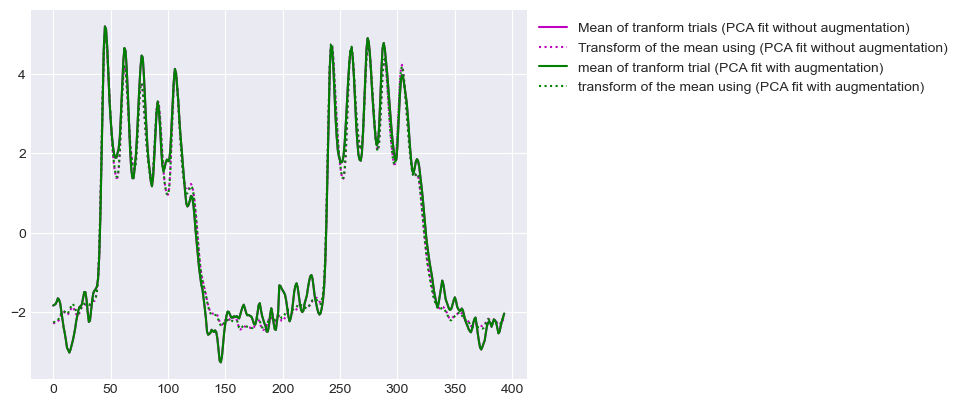

In [10]:
plt.plot(transform.mean(0)[0, :].T, c = 'm', label = 'Mean of tranform trials (PCA fit without augmentation)' )
plt.plot(ts[0, :], c='m', ls=':', label = 'Transform of the mean using (PCA fit without augmentation) ')

plt.plot(transform1.mean(0)[0, :], c='g', label = 'mean of tranform trial (PCA fit with augmentation)' )
plt.plot(ts1[0, :],c='g', ls=':' , label = 'transform of the mean using (PCA fit with augmentation) ')
plt.legend(bbox_to_anchor = (1, 1))
plt.grid()